# Simulación de trayectorias del precio

Hasta ahora se saltaba directo de $S_0$ a $S_T$ con un solo paso. Ahora se
construye el camino completo: el año se divide en 252 días hábiles y se avanza
día por día.

$$S_{t+1} = S_t \exp\left[\left(r - \tfrac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\,Z_t\right]$$

donde $\Delta t = T/n = 1/252$.

Es la misma fórmula de antes, pero aplicada sobre intervalos pequeños en lugar
de sobre el año entero. Cada paso usa su propio $Z$ independiente, y el precio
resultante se convierte en el punto de partida del paso siguiente.

**Parámetros:** $S_0 = 100$, $K = 110$, $r = 5\%$, $\sigma = 20\%$, $T = 1$,
50 trayectorias, 252 pasos.

In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

S0, K, r, sigma, T = 100, 110, 0.05, 0.20, 1
n = 252              # pasos en el año
M = 50               # trayectorias
dt = T / n

np.random.seed(42)

# Matriz de choques aleatorios: una fila por trayectoria, una columna por paso
Z = np.random.normal(0, 1, (M, n))

# Matriz de precios: empieza en ceros y se va llenando
S = np.zeros((M, n + 1))
S[:, 0] = S0                         # primera columna: el precio inicial

print(f"dt              : {dt:.6f}")
print(f"Matriz Z        : {Z.shape}   (50 trayectorias x 252 pasos)")
print(f"Matriz S        : {S.shape}   (una columna extra para S0)")
print(f"\nPrimeras filas de S antes de llenar:")
print(S[:3, :5])

dt              : 0.003968
Matriz Z        : (50, 252)   (50 trayectorias x 252 pasos)
Matriz S        : (50, 253)   (una columna extra para S0)

Primeras filas de S antes de llenar:
[[100.   0.   0.   0.   0.]
 [100.   0.   0.   0.   0.]
 [100.   0.   0.   0.   0.]]


In [27]:
for t in range(1, n + 1):
    S[:, t] = S[:, t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:, t-1])

ST = S[:, -1]        # última columna: precios al vencimiento

print(f"Trayectorias simuladas : {M}")
print(f"E[S_T] simulado        : {ST.mean():.2f}   (teórico: {S0*np.exp(r*T):.2f})")
print(f"Mediana                : {np.median(ST):.2f}")
print(f"Mínimo / Máximo        : {ST.min():.2f} / {ST.max():.2f}")
print(f"Trayectorias que suben : {(ST > S0).sum()} de {M}")
print(f"Terminan ITM           : {(ST > K).mean():.2%}")

Trayectorias simuladas : 50
E[S_T] simulado        : 102.98   (teórico: 105.13)
Mediana                : 101.86
Mínimo / Máximo        : 74.29 / 165.53
Trayectorias que suben : 26 de 50
Terminan ITM           : 28.00%


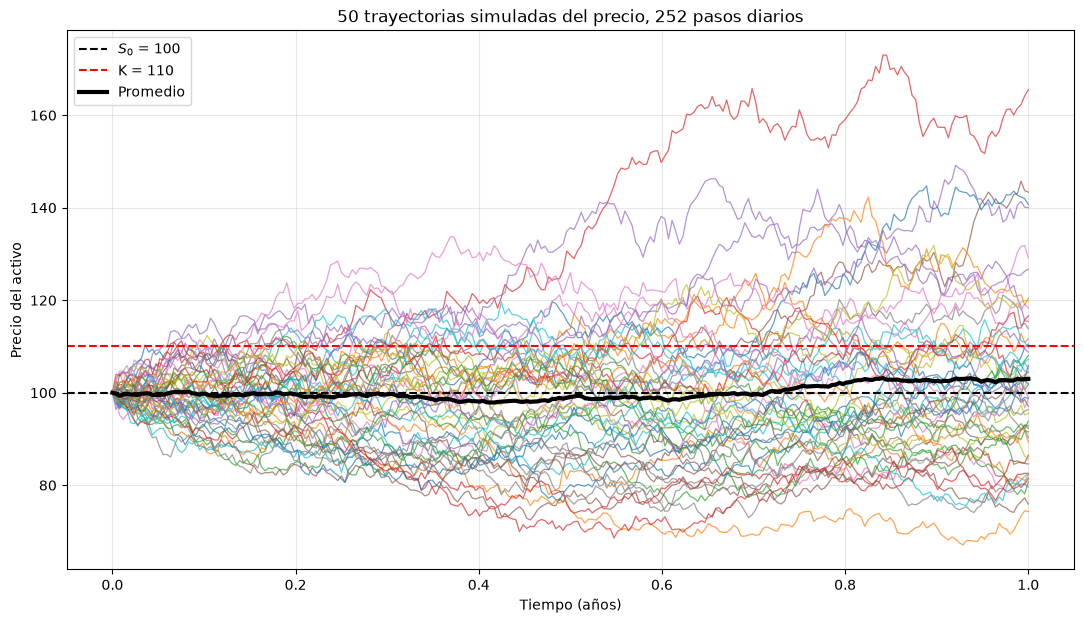

In [28]:
tiempo = np.linspace(0, T, n + 1)

plt.figure(figsize=(13, 7))

for i in range(M):
    plt.plot(tiempo, S[i, :], lw=0.9, alpha=0.7)

plt.axhline(S0, color='black', ls='--', lw=1.5, label=f'$S_0$ = {S0}')
plt.axhline(K,  color='red',   ls='--', lw=1.5, label=f'K = {K}')
plt.plot(tiempo, S.mean(axis=0), color='black', lw=3, label='Promedio')

plt.xlabel('Tiempo (años)')
plt.ylabel('Precio del activo')
plt.title(f'{M} trayectorias simuladas del precio, {n} pasos diarios')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

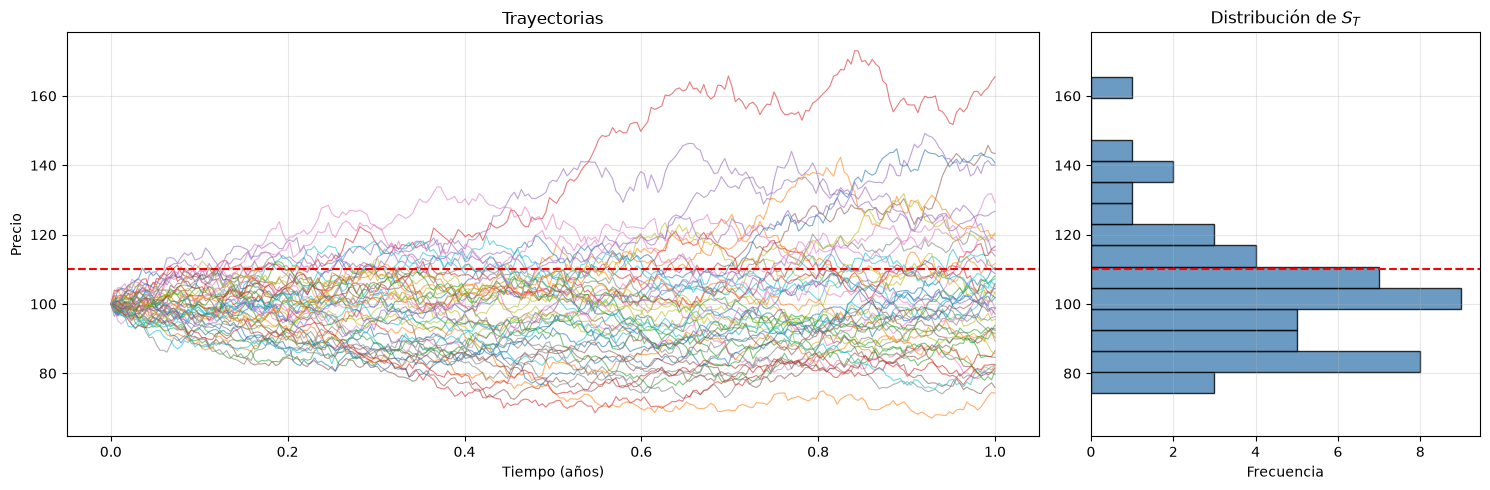

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                         gridspec_kw={'width_ratios': [2.5, 1]})

for i in range(M):
    axes[0].plot(tiempo, S[i, :], lw=0.8, alpha=0.6)
axes[0].axhline(K, color='red', ls='--', lw=1.5)
axes[0].set_xlabel('Tiempo (años)'); axes[0].set_ylabel('Precio')
axes[0].set_title('Trayectorias')
axes[0].grid(alpha=0.3)

axes[1].hist(ST, bins=15, orientation='horizontal',
             color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axhline(K, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Frecuencia')
axes[1].set_title('Distribución de $S_T$')
axes[1].grid(alpha=0.3)

axes[1].set_ylim(axes[0].get_ylim())
plt.tight_layout()
plt.show()

In [30]:
payoff = np.maximum(ST - K, 0)
precio = np.exp(-r*T) * payoff.mean()

print(f"Precio del call con {M} trayectorias : {precio:.4f}")
print(f"Black-Scholes                        : 10.4506")
print(f"Diferencia                           : {abs(precio - 10.4506):.4f}")
print(f"Error estándar                       : {np.exp(-r*T)*payoff.std(ddof=1)/np.sqrt(M):.4f}")

Precio del call con 50 trayectorias : 4.4161
Black-Scholes                        : 10.4506
Diferencia                           : 6.0345
Error estándar                       : 1.4855


## Envolvente del intervalo de confianza al 95%

En cada instante $t$, el logaritmo del precio se distribuye normal:

$$\ln(S_t) \sim N\left(\ln S_0 + \left(r - \tfrac{\sigma^2}{2}\right)t,\ \sigma^2 t\right)$$

Despejando los límites del 95% y volviendo a niveles de precio:

$$S_t^{\,\pm} = S_0 \exp\left[\left(r - \tfrac{\sigma^2}{2}\right)t \pm 1.96\,\sigma\sqrt{t}\right]$$

La banda arranca en un punto, porque en $t=0$ el precio se conoce con certeza,
y se va abriendo conforme se acumula incertidumbre.

In [31]:
z = 1.96

banda_inf = S0 * np.exp((r - 0.5*sigma**2)*tiempo - z*sigma*np.sqrt(tiempo))
banda_sup = S0 * np.exp((r - 0.5*sigma**2)*tiempo + z*sigma*np.sqrt(tiempo))
mediana   = S0 * np.exp((r - 0.5*sigma**2)*tiempo)

dentro = ((ST >= banda_inf[-1]) & (ST <= banda_sup[-1])).sum()

print(f"IC 95% en T = 0.5 : [{banda_inf[126]:.2f}, {banda_sup[126]:.2f}]")
print(f"IC 95% en T = 1   : [{banda_inf[-1]:.2f}, {banda_sup[-1]:.2f}]")
print(f"Mediana en T = 1  : {mediana[-1]:.2f}")
print(f"\nTrayectorias dentro de la banda al vencimiento: {dentro} de {M} ({dentro/M:.0%})")

IC 95% en T = 0.5 : [76.94, 133.94]
IC 95% en T = 1   : [69.63, 152.50]
Mediana en T = 1  : 103.05

Trayectorias dentro de la banda al vencimiento: 49 de 50 (98%)


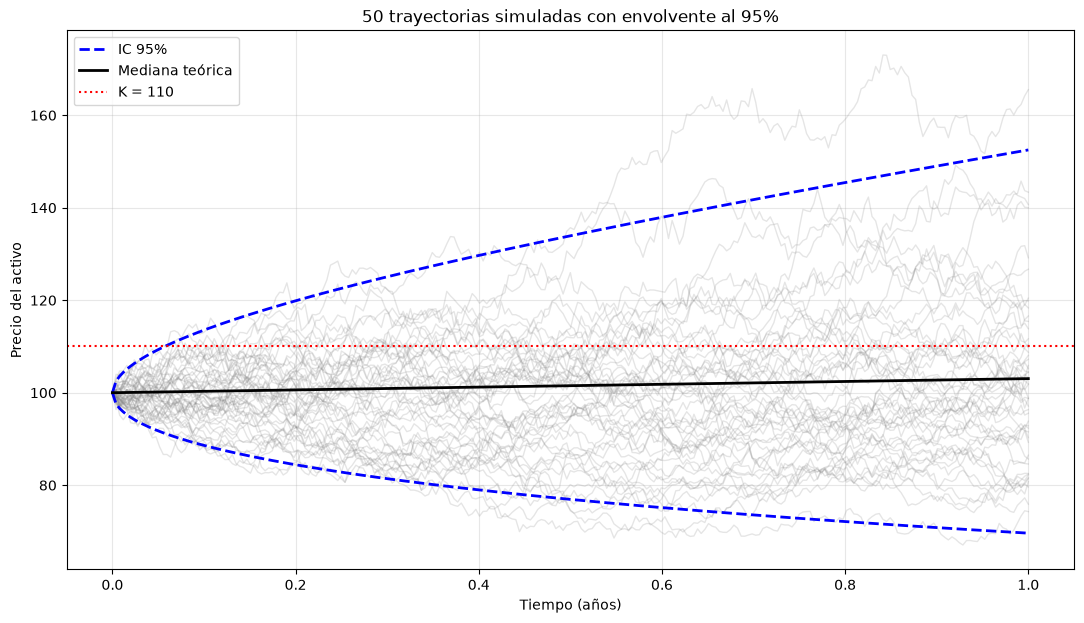

In [32]:
plt.figure(figsize=(13, 7))

for i in range(M):
    plt.plot(tiempo, S[i, :], color='gray', alpha=0.2, lw=1)

plt.plot(tiempo, banda_sup, color='blue', linestyle='--', lw=2, label='IC 95%')
plt.plot(tiempo, banda_inf, color='blue', linestyle='--', lw=2)
plt.plot(tiempo, mediana, color='black', lw=2, label='Mediana teórica')

plt.axhline(K, color='red', ls=':', lw=1.5, label=f'K = {K}')

plt.xlabel('Tiempo (años)')
plt.ylabel('Precio del activo')
plt.title(f'{M} trayectorias simuladas con envolvente al 95%')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

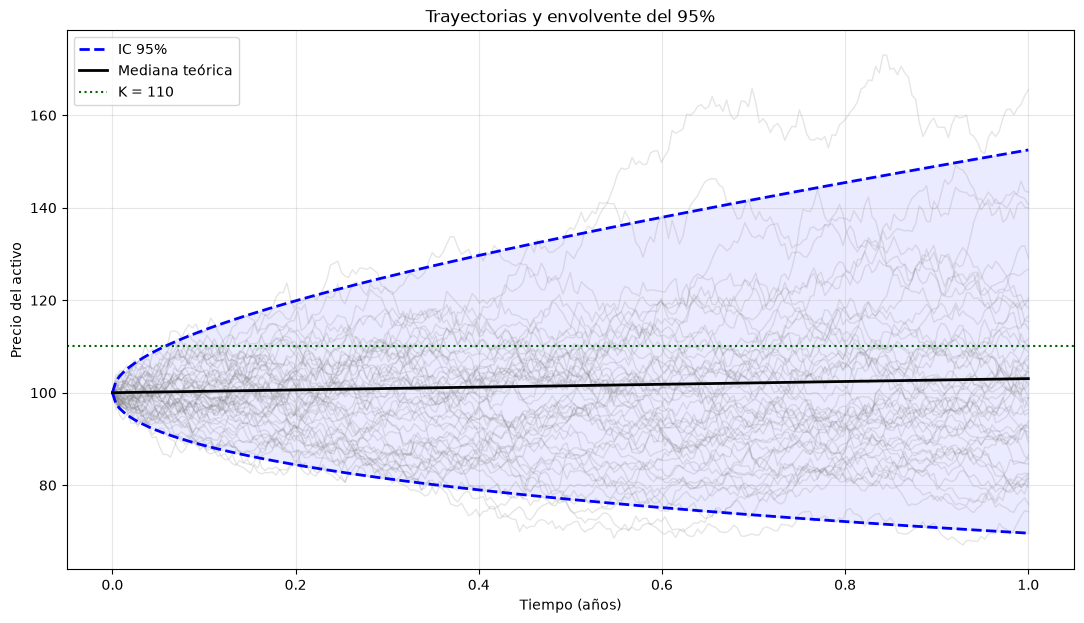

In [33]:
# version con k = 110, y relleno en el intervalo de confianza
K = 110

plt.figure(figsize=(13, 7))

plt.fill_between(tiempo, banda_inf, banda_sup, color='blue', alpha=0.08)

for i in range(M):
    plt.plot(tiempo, S[i, :], color='gray', alpha=0.2, lw=1)

plt.plot(tiempo, banda_sup, color='blue', linestyle='--', lw=2, label='IC 95%')
plt.plot(tiempo, banda_inf, color='blue', linestyle='--', lw=2)
plt.plot(tiempo, mediana, color='black', lw=2, label='Mediana teórica')

plt.axhline(K, color='darkgreen', ls=':', lw=1.5, label=f'K = {K}')

plt.xlabel('Tiempo (años)')
plt.ylabel('Precio del activo')
plt.title('Trayectorias y envolvente del 95%')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Version con bandas empiricas

In [34]:
banda_inf = np.percentile(S, 2.5,  axis=0)
banda_sup = np.percentile(S, 97.5, axis=0)
mediana   = np.percentile(S, 50,   axis=0)

print(f"IC 95% en T = 0.5 : [{banda_inf[126]:.2f}, {banda_sup[126]:.2f}]")
print(f"IC 95% en T = 1   : [{banda_inf[-1]:.2f}, {banda_sup[-1]:.2f}]")
print(f"Mediana en T = 1  : {mediana[-1]:.2f}")

IC 95% en T = 0.5 : [74.51, 128.93]
IC 95% en T = 1   : [76.74, 142.76]
Mediana en T = 1  : 101.86


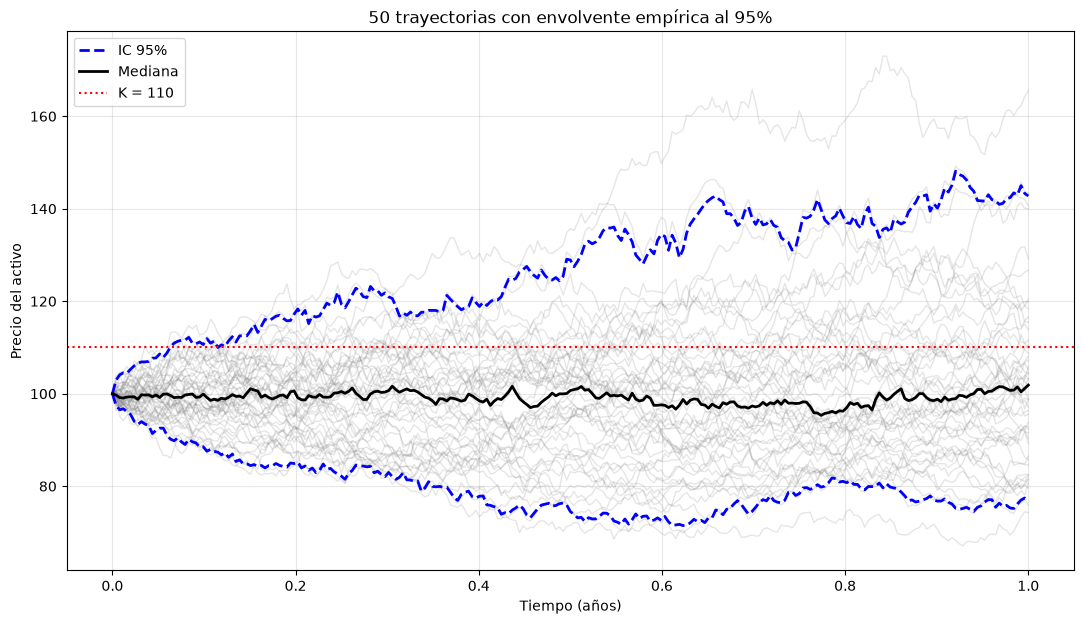

In [35]:
plt.figure(figsize=(13, 7))

for i in range(M):
    plt.plot(tiempo, S[i, :], color='gray', alpha=0.2, lw=1)

plt.plot(tiempo, banda_sup, color='blue', linestyle='--', lw=2, label='IC 95%')
plt.plot(tiempo, banda_inf, color='blue', linestyle='--', lw=2)
plt.plot(tiempo, mediana, color='black', lw=2, label='Mediana')

plt.axhline(K, color='red', ls=':', lw=1.5, label=f'K = {K}')

plt.xlabel('Tiempo (años)')
plt.ylabel('Precio del activo')
plt.title(f'{M} trayectorias con envolvente empírica al 95%')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Comparacion con banda teorica

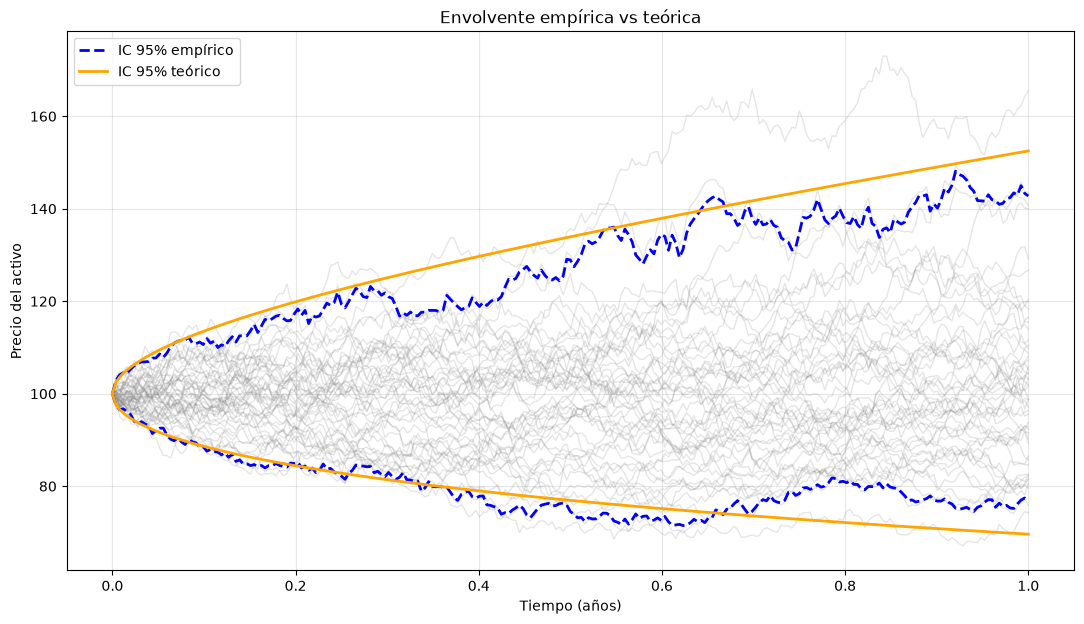

In [36]:
z = 1.96
teo_inf = S0 * np.exp((r - 0.5*sigma**2)*tiempo - z*sigma*np.sqrt(tiempo))
teo_sup = S0 * np.exp((r - 0.5*sigma**2)*tiempo + z*sigma*np.sqrt(tiempo))

plt.figure(figsize=(13, 7))

for i in range(M):
    plt.plot(tiempo, S[i, :], color='gray', alpha=0.2, lw=1)

plt.plot(tiempo, banda_sup, color='blue', linestyle='--', lw=2, label='IC 95% empírico')
plt.plot(tiempo, banda_inf, color='blue', linestyle='--', lw=2)
plt.plot(tiempo, teo_sup, color='orange', lw=2, label='IC 95% teórico')
plt.plot(tiempo, teo_inf, color='orange', lw=2)

plt.xlabel('Tiempo (años)')
plt.ylabel('Precio del activo')
plt.title('Envolvente empírica vs teórica')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Simulación de 1,000 trayectorias

Para cada trayectoria se guardan dos cantidades:

- $S_T$: el precio al final del año, que es lo único que mira una opción europea.
- $\hat{S}$: el promedio de los 252 precios diarios de esa trayectoria.

El promedio solo tiene sentido si se simula el camino completo. Es lo que
subyace a las opciones asiáticas, donde el payoff depende del precio promedio
durante la vida del contrato y no del precio final.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

S0, K, r, sigma, T = 100, 110, 0.05, 0.20, 1
n = 252
M = 1000
dt = T / n

np.random.seed(42)

Z = np.random.normal(0, 1, (M, n))
S = np.zeros((M, n + 1))
S[:, 0] = S0

for t in range(1, n + 1):
    S[:, t] = S[:, t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:, t-1])

ST    = S[:, -1]                  # precio final
S_hat = S[:, 1:].mean(axis=1)     # promedio de los 252 precios observados

print(f"Matriz S : {S.shape}")
print(f"Matriz Z : {Z.shape}")

Matriz S : (1000, 253)
Matriz Z : (1000, 252)


In [38]:
tabla = pd.DataFrame({
    'Trayectoria': np.arange(1, M + 1),
    'S_T': ST,
    'S_hat': S_hat
})

print(tabla.head(10).round(4).to_string(index=False))
print()
print(tabla[['S_T', 'S_hat']].describe().round(4).to_string())

 Trayectoria      S_T    S_hat
           1 101.8211  93.6000
           2 111.6530 108.2035
           3  80.7536  88.0323
           4 165.5282 135.6060
           5 140.0235 126.6987
           6 143.3622 109.8488
           7 129.1796 103.9250
           8  92.8441  91.3297
           9  95.5663  95.8567
          10 109.7476 107.2042

             S_T      S_hat
count  1000.0000  1000.0000
mean    105.0866   102.2072
std      20.7792    11.9831
min      54.1645    72.9051
25%      89.6267    93.9224
50%     103.8743   101.6850
75%     117.6355   109.8619
max     179.3853   143.1923


In [39]:
print(f"{'':12} {'S_T':>10} {'S_hat':>10}")
print(f"{'Media':12} {ST.mean():>10.2f} {S_hat.mean():>10.2f}")
print(f"{'Mediana':12} {np.median(ST):>10.2f} {np.median(S_hat):>10.2f}")
print(f"{'Desv. est.':12} {ST.std():>10.2f} {S_hat.std():>10.2f}")
print(f"{'Mínimo':12} {ST.min():>10.2f} {S_hat.min():>10.2f}")
print(f"{'Máximo':12} {ST.max():>10.2f} {S_hat.max():>10.2f}")
print(f"\nCorrelación entre S_T y S_hat : {np.corrcoef(ST, S_hat)[0,1]:.4f}")
print(f"Razón de dispersiones         : {S_hat.std()/ST.std():.4f}")

                    S_T      S_hat
Media            105.09     102.21
Mediana          103.87     101.69
Desv. est.        20.77      11.98
Mínimo            54.16      72.91
Máximo           179.39     143.19

Correlación entre S_T y S_hat : 0.8674
Razón de dispersiones         : 0.5767


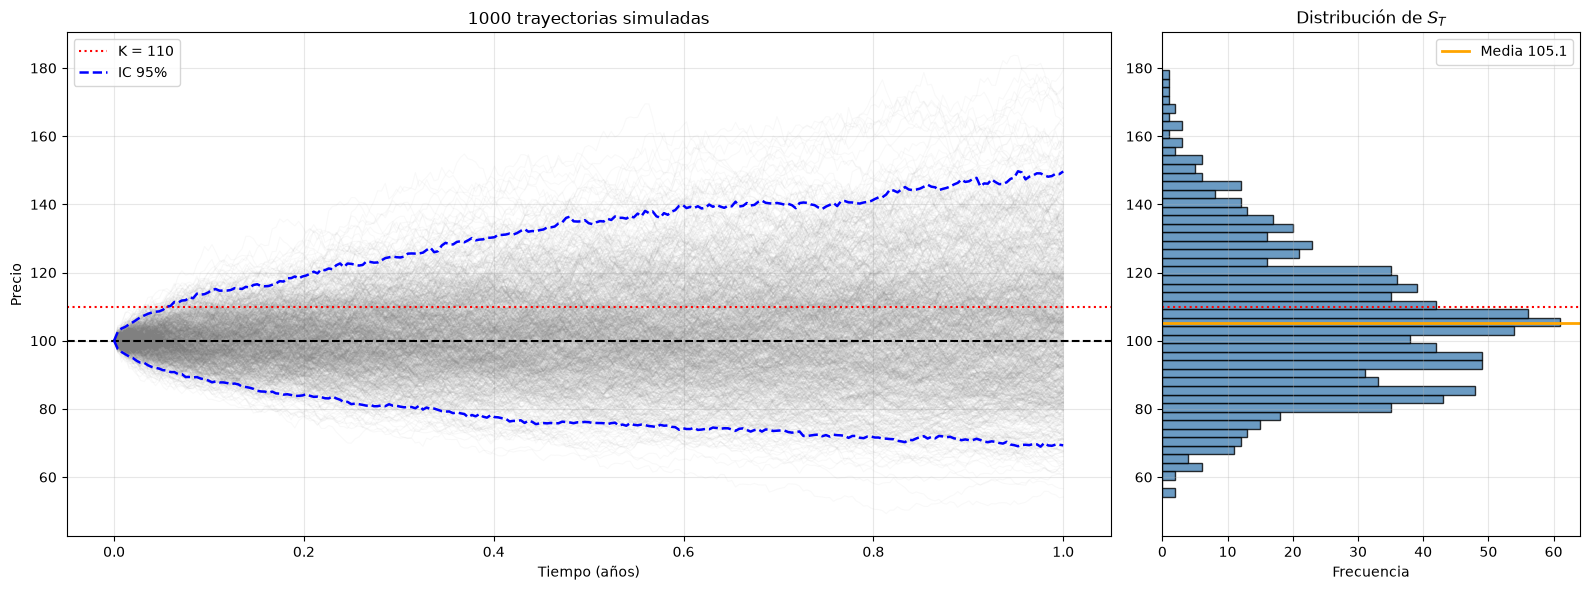

In [40]:
#Histograma de ST
K = 110
tiempo = np.linspace(0, T, n + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={'width_ratios': [2.5, 1]})

for i in range(M):
    axes[0].plot(tiempo, S[i, :], color='gray', alpha=0.05, lw=0.8)

axes[0].axhline(S0, color='black', ls='--', lw=1.5)
axes[0].axhline(K, color='red', ls=':', lw=1.5, label=f'K = {K}')
axes[0].plot(tiempo, np.percentile(S, 2.5, axis=0),  color='blue', ls='--', lw=1.8, label='IC 95%')
axes[0].plot(tiempo, np.percentile(S, 97.5, axis=0), color='blue', ls='--', lw=1.8)
axes[0].set_xlabel('Tiempo (años)'); axes[0].set_ylabel('Precio')
axes[0].set_title(f'{M} trayectorias simuladas')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(ST, bins=50, orientation='horizontal',
             color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axhline(K, color='red', ls=':', lw=1.5)
axes[1].axhline(ST.mean(), color='orange', lw=2, label=f'Media {ST.mean():.1f}')
axes[1].set_xlabel('Frecuencia')
axes[1].set_title('Distribución de $S_T$')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(axes[0].get_ylim())

plt.tight_layout()
plt.show()

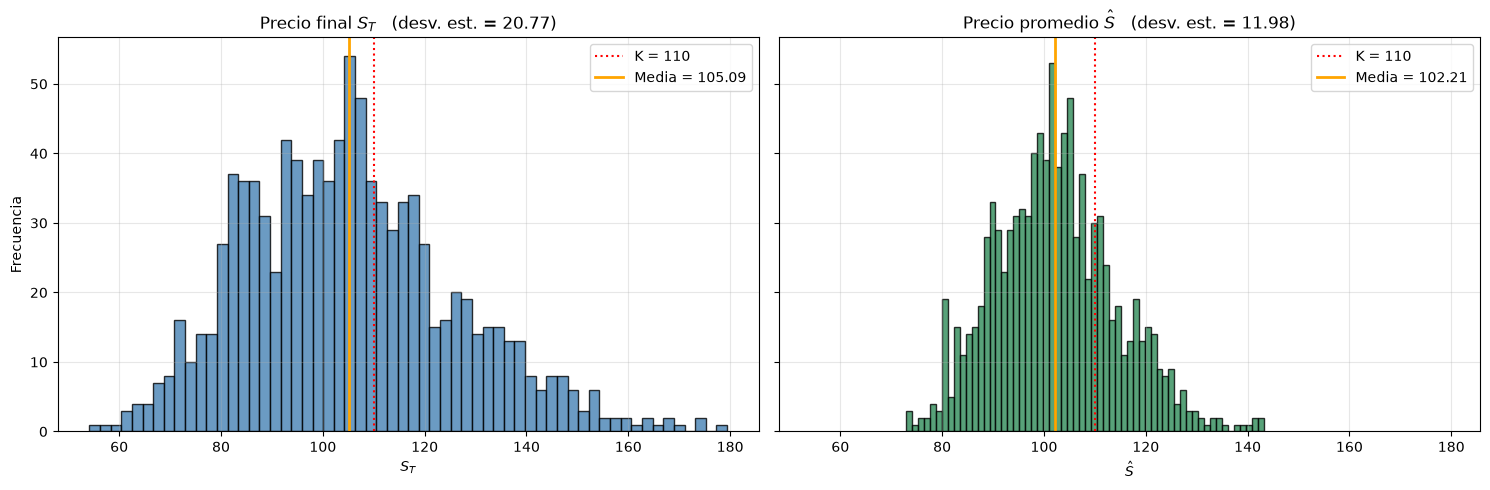

In [41]:
# Comparacion con histograma de S_hat

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)

axes[0].hist(ST, bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(K, color='red', ls=':', lw=1.5, label=f'K = {K}')
axes[0].axvline(ST.mean(), color='orange', lw=2, label=f'Media = {ST.mean():.2f}')
axes[0].set_xlabel('$S_T$'); axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'Precio final $S_T$   (desv. est. = {ST.std():.2f})')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(S_hat, bins=60, color='seagreen', edgecolor='black', alpha=0.8)
axes[1].axvline(K, color='red', ls=':', lw=1.5, label=f'K = {K}')
axes[1].axvline(S_hat.mean(), color='orange', lw=2, label=f'Media = {S_hat.mean():.2f}')
axes[1].set_xlabel('$\\hat{S}$')
axes[1].set_title(f'Precio promedio $\\hat{{S}}$   (desv. est. = {S_hat.std():.2f})')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

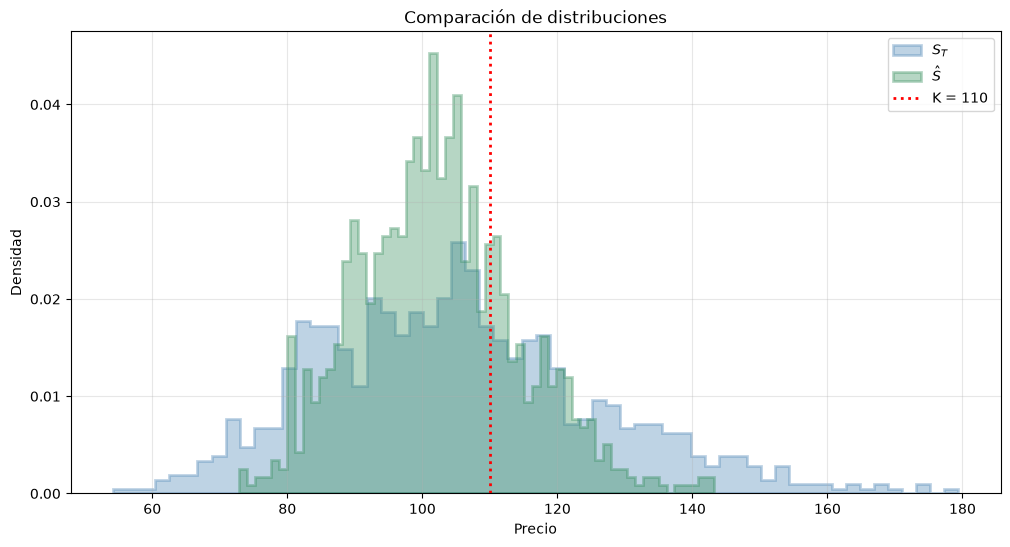

In [42]:
plt.figure(figsize=(12, 6))

plt.hist(ST,    bins=60, density=True, histtype='stepfilled', lw=2,
         color='steelblue', edgecolor='steelblue', alpha=0.35, label='$S_T$')
plt.hist(S_hat, bins=60, density=True, histtype='stepfilled', lw=2,
         color='seagreen', edgecolor='seagreen', alpha=0.35, label='$\\hat{S}$')

plt.axvline(K, color='red', ls=':', lw=2, label=f'K = {K}')
plt.xlabel('Precio'); plt.ylabel('Densidad')
plt.title('Comparación de distribuciones')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Opciones europeas vs asiáticas

La diferencia está únicamente en qué precio mira el payoff al vencimiento:

| | Call | Put |
|---|---|---|
| **Europea** | $\max(S_T - K, 0)$ | $\max(K - S_T, 0)$ |
| **Asiática** | $\max(\hat{S} - K, 0)$ | $\max(K - \hat{S}, 0)$ |

donde $\hat{S}$ es el promedio de los 252 precios diarios de la trayectoria.

Ambas se valúan igual: se descuenta el promedio del payoff a la tasa libre de
riesgo. La asiática no tiene fórmula cerrada porque el promedio de variables
lognormales no es lognormal, así que Monte Carlo es el único camino.

In [43]:
descuento = np.exp(-r*T)

payoff_call_eu = np.maximum(ST    - K, 0)
payoff_put_eu  = np.maximum(K - ST,    0)
payoff_call_as = np.maximum(S_hat - K, 0)
payoff_put_as  = np.maximum(K - S_hat, 0)

resumen = pd.DataFrame({
    'Opción': ['Call europea', 'Call asiática', 'Put europea', 'Put asiática'],
    'Payoff promedio': [payoff_call_eu.mean(), payoff_call_as.mean(),
                        payoff_put_eu.mean(),  payoff_put_as.mean()],
    'Precio': [descuento*payoff_call_eu.mean(), descuento*payoff_call_as.mean(),
               descuento*payoff_put_eu.mean(),  descuento*payoff_put_as.mean()],
    'P(ITM)': [(ST > K).mean(), (S_hat > K).mean(),
               (ST < K).mean(), (S_hat < K).mean()],
    'Desv. est. payoff': [payoff_call_eu.std(ddof=1), payoff_call_as.std(ddof=1),
                          payoff_put_eu.std(ddof=1),  payoff_put_as.std(ddof=1)]
})

print(resumen.round(4).to_string(index=False))

       Opción  Payoff promedio  Precio  P(ITM)  Desv. est. payoff
 Call europea           6.1704  5.8694   0.362            11.6640
Call asiática           1.9999  1.9023   0.242             4.9470
  Put europea          11.0837 10.5432   0.638            12.6019
 Put asiática           9.7927  9.3151   0.758             8.9394


In [44]:
call_eu = descuento * payoff_call_eu.mean()
call_as = descuento * payoff_call_as.mean()
put_eu  = descuento * payoff_put_eu.mean()
put_as  = descuento * payoff_put_as.mean()

print(f"{'':16} {'Europea':>10} {'Asiática':>10} {'Razón':>8}")
print(f"{'Call':16} {call_eu:>10.4f} {call_as:>10.4f} {call_as/call_eu:>8.2%}")
print(f"{'Put':16} {put_eu:>10.4f} {put_as:>10.4f} {put_as/put_eu:>8.2%}")
print()
print(f"Black-Scholes call : 10.4506   (referencia para la europea)")
print(f"Black-Scholes put  :  5.5735")

                    Europea   Asiática    Razón
Call                 5.8694     1.9023   32.41%
Put                 10.5432     9.3151   88.35%

Black-Scholes call : 10.4506   (referencia para la europea)
Black-Scholes put  :  5.5735


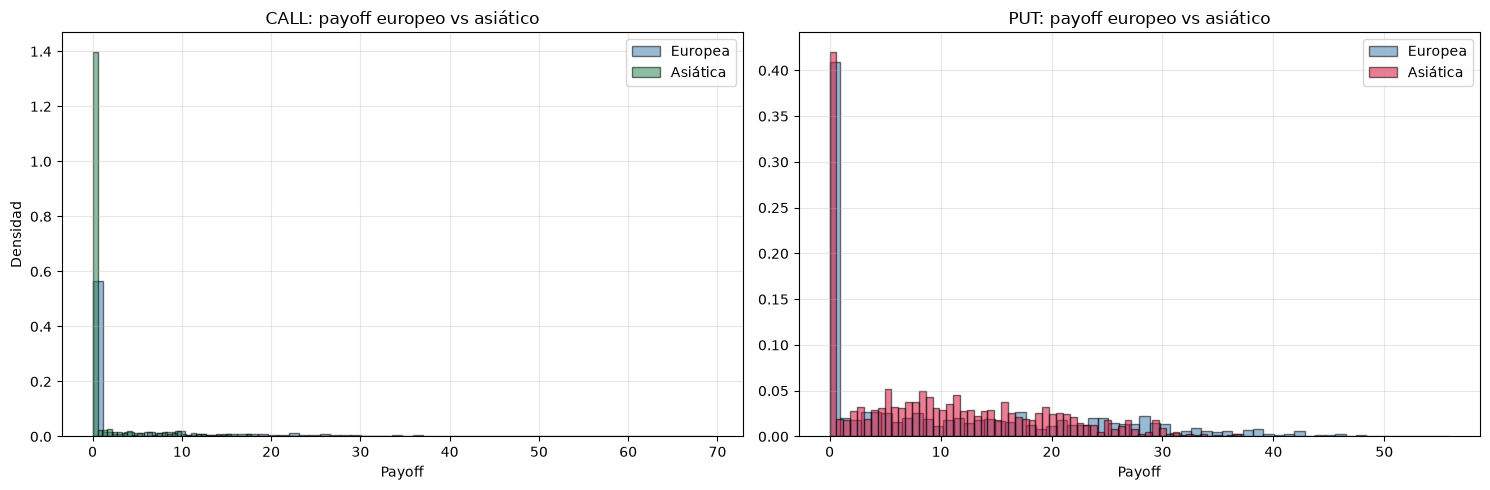

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(payoff_call_eu, bins=60, density=True, color='steelblue',
             edgecolor='black', alpha=0.55, label='Europea')
axes[0].hist(payoff_call_as, bins=60, density=True, color='seagreen',
             edgecolor='black', alpha=0.55, label='Asiática')
axes[0].set_xlabel('Payoff'); axes[0].set_ylabel('Densidad')
axes[0].set_title('CALL: payoff europeo vs asiático')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(payoff_put_eu, bins=60, density=True, color='steelblue',
             edgecolor='black', alpha=0.55, label='Europea')
axes[1].hist(payoff_put_as, bins=60, density=True, color='crimson',
             edgecolor='black', alpha=0.55, label='Asiática')
axes[1].set_xlabel('Payoff')
axes[1].set_title('PUT: payoff europeo vs asiático')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

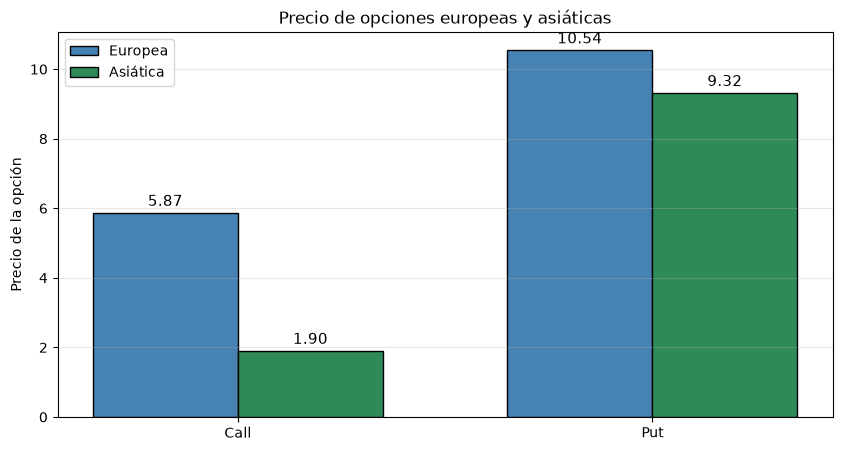

In [46]:
plt.figure(figsize=(10, 5))

etiquetas = ['Call', 'Put']
x = np.arange(len(etiquetas))
ancho = 0.35

plt.bar(x - ancho/2, [call_eu, put_eu], ancho, color='steelblue',
        edgecolor='black', label='Europea')
plt.bar(x + ancho/2, [call_as, put_as], ancho, color='seagreen',
        edgecolor='black', label='Asiática')

for i, (e, a) in enumerate(zip([call_eu, put_eu], [call_as, put_as])):
    plt.text(i - ancho/2, e + 0.2, f'{e:.2f}', ha='center', fontsize=11)
    plt.text(i + ancho/2, a + 0.2, f'{a:.2f}', ha='center', fontsize=11)

plt.xticks(x, etiquetas)
plt.ylabel('Precio de la opción')
plt.title('Precio de opciones europeas y asiáticas')
plt.legend(); plt.grid(alpha=0.3, axis='y')
plt.show()

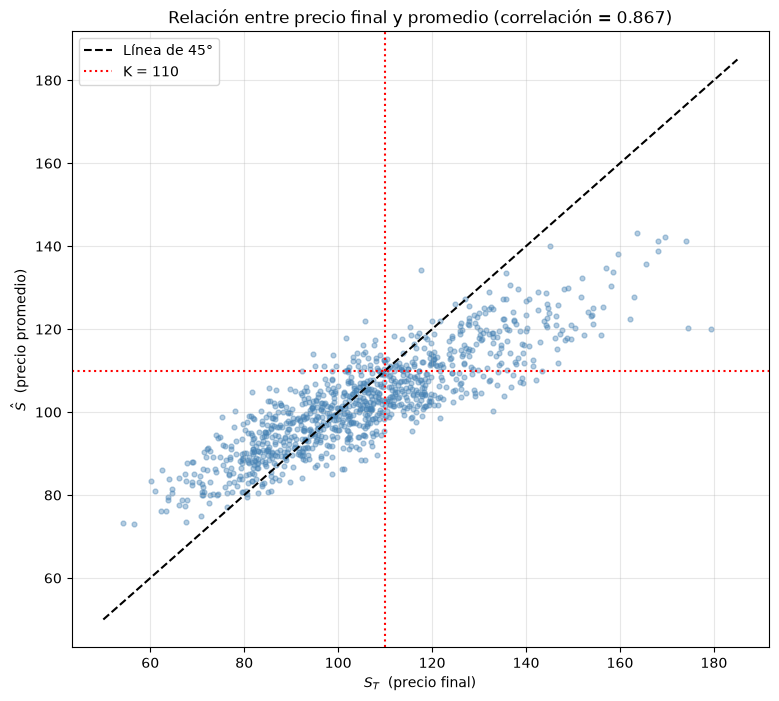

In [47]:
plt.figure(figsize=(9, 8))

plt.scatter(ST, S_hat, s=12, alpha=0.4, color='steelblue')
plt.plot([50, 185], [50, 185], color='black', ls='--', lw=1.5, label='Línea de 45°')
plt.axvline(K, color='red', ls=':', lw=1.5)
plt.axhline(K, color='red', ls=':', lw=1.5, label=f'K = {K}')

plt.xlabel('$S_T$  (precio final)')
plt.ylabel('$\\hat{S}$  (precio promedio)')
plt.title(f'Relación entre precio final y promedio (correlación = {np.corrcoef(ST, S_hat)[0,1]:.3f})')
plt.legend(); plt.grid(alpha=0.3)
plt.show()